# 第二课：多模态 Token 探秘 —— 图片、视频、声音如何变成 Token？

在 [第一课](../01-token_journey/token_journey.ipynb) 中，我们已经深入了解了文本如何被切分为 Token、编码为 ID、嵌入为向量，最终被 Transformer 处理。但世界不只是文本 —— 我们看图片、看视频、听声音，这些信息又是如何变成模型能理解的 Token 的呢？

这节课我们将探索：
- **视觉 Token**：图片如何被切分为 Patch，再变成和文本 Token 同等地位的向量？
- **视频 Token**：视频的时空信息如何被编码？
- **音频 Token**：声音波形如何被量化为离散的 Token？TTS 又如何从 Token 生成语音？
- **多模态融合**：不同模态的 Token 如何在同一个 Transformer 中共存？
- **语音交互**：用语音提问、让模型语音回答，体验真正的多模态交互！

我们将使用 **Qwen3.5-0.8B** 模型作为实验对象 —— 它是 Qwen3.5 家族中最小的成员，但和所有 Qwen3.5 模型一样，**原生支持图片和视频输入**，不需要单独的"VL"版本。我们会用可爱的 **乖乖** 图片和一段开源视频来实际验证。

In [1]:
from modelscope import snapshot_download
from transformers import AutoTokenizer, AutoProcessor, Qwen3_5ForConditionalGeneration, TextIteratorStreamer
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import json
import os
import sys
import logging
import tempfile
from threading import Thread

logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("modelscope").setLevel(logging.ERROR)

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
ASSETS_DIR = os.path.join(NOTEBOOK_DIR, "assets")

tokenizer_id = "Qwen/Qwen3.5-0.8B"
model_dir = snapshot_download(tokenizer_id)
tokenizer = AutoTokenizer.from_pretrained(model_dir, local_files_only=True)
processor = AutoProcessor.from_pretrained(model_dir, local_files_only=True)

print(f"模型: {tokenizer_id}")
print(f"词表大小: {len(tokenizer)}")
print(f"Processor 类型: {type(processor).__name__}")

模型: Qwen/Qwen3.5-0.8B
词表大小: 248077
Processor 类型: Qwen3VLProcessor


## 1. 视觉 Token：图片如何变成 Token？

在第一课中，我们看到文本通过 BPE 分词器被切分为 Token。那图片呢？图片是一个二维的像素矩阵，没有"空格"或"词边界"可以切分。

答案是 **ViT (Vision Transformer)** 思想：将图片切成固定大小的小块（Patch），每个小块就是一个"视觉 Token"。

具体过程如下：

1. **调整大小**：将输入图片调整到模型需要的分辨率。
2. **切分 Patch**：将图片切成 $P \times P$ 的小块（Qwen3.5 使用 $16 \times 16$ 的 Patch）。
3. **展平 + 线性映射**：每个 Patch 展平为一维向量，再通过一个线性层映射到与文本 Token 相同的维度。
4. **空间合并**：将相邻的 $2 \times 2$ 个 Patch 合并，减少 Token 数量，提高效率。
5. **添加位置编码**：为每个视觉 Token 加上位置信息，让模型知道它们在图片中的位置。

让我们用可爱的 **乖乖** 图片来直观感受这个过程：

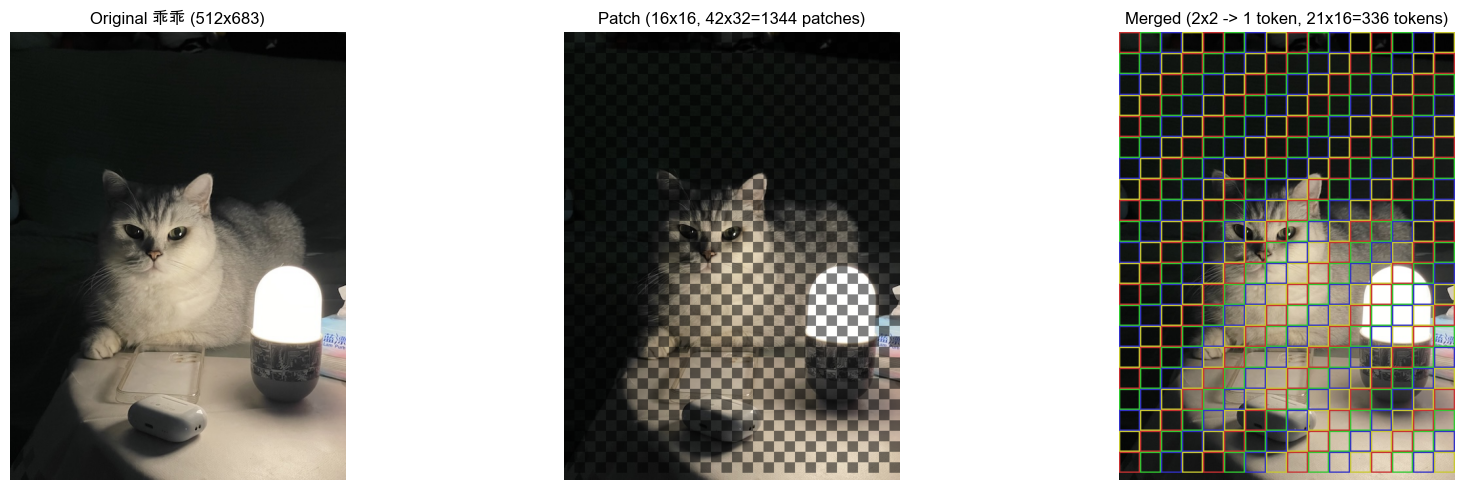


=== 视觉 Token 数量计算 ===
图片尺寸: 512x683
Patch 尺寸: 16x16
原始 Patch 数量: 42x32 = 1344
空间合并 (2x2): 21x16 = 336 个视觉 Token

对比: 同样的乖乖图片
  文本 Token: 一句话通常只有 10-30 个 Token
  视觉 Token: 一张图片就需要 336 个 Token!


In [2]:
demo_img_path = os.path.join(ASSETS_DIR, "guaiguai.jpg")
demo_img = Image.open(demo_img_path)
img_w, img_h = demo_img.size

patch_size = 16
merge_size = 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(demo_img)
axes[0].set_title(f"Original 乖乖 ({img_w}x{img_h})")
axes[0].axis('off')

img_arr = np.array(demo_img)
patched = img_arr.copy()
n_patches_h = img_h // patch_size
n_patches_w = img_w // patch_size
for i in range(n_patches_h):
    for j in range(n_patches_w):
        if (i + j) % 2 == 0:
            patched[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size] \
                = (patched[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size] * 0.5).astype(np.uint8)
axes[1].imshow(patched)
axes[1].set_title(f"Patch ({patch_size}x{patch_size}, {n_patches_h}x{n_patches_w}={n_patches_h*n_patches_w} patches)")
axes[1].axis('off')

merged_h = n_patches_h // merge_size
merged_w = n_patches_w // merge_size
merged_vis = img_arr.copy()
colors = np.array([[200, 50, 50], [50, 200, 50], [50, 50, 200], [200, 200, 50]])
for i in range(merged_h):
    for j in range(merged_w):
        c = colors[(i + j) % 4]
        y1, y2 = i * patch_size * merge_size, (i + 1) * patch_size * merge_size
        x1, x2 = j * patch_size * merge_size, (j + 1) * patch_size * merge_size
        merged_vis[y1:y1+2, x1:x2] = c
        merged_vis[y2-2:y2, x1:x2] = c
        merged_vis[y1:y2, x1:x1+2] = c
        merged_vis[y1:y2, x2-2:x2] = c
if n_patches_h % merge_size != 0:
    y_start = merged_h * patch_size * merge_size
    y_end = n_patches_h * patch_size
    for j in range(merged_w):
        c = colors[(merged_h + j) % 4]
        x1, x2 = j * patch_size * merge_size, (j + 1) * patch_size * merge_size
        merged_vis[y_start:y_start+2, x1:x2] = c
        merged_vis[y_end-2:y_end, x1:x2] = c
        merged_vis[y_start:y_end, x1:x1+2] = c
        merged_vis[y_start:y_end, x2-2:x2] = c
if n_patches_w % merge_size != 0:
    x_start = merged_w * patch_size * merge_size
    x_end = n_patches_w * patch_size
    for i in range(merged_h):
        c = colors[(i + merged_w) % 4]
        y1, y2 = i * patch_size * merge_size, (i + 1) * patch_size * merge_size
        merged_vis[y1:y1+2, x_start:x_end] = c
        merged_vis[y2-2:y2, x_start:x_end] = c
        merged_vis[y1:y2, x_start:x_start+2] = c
        merged_vis[y1:y2, x_end-2:x_end] = c
if n_patches_h % merge_size != 0 and n_patches_w % merge_size != 0:
    c = colors[(merged_h + merged_w) % 4]
    y1, y2 = merged_h * patch_size * merge_size, n_patches_h * patch_size
    x1, x2 = merged_w * patch_size * merge_size, n_patches_w * patch_size
    merged_vis[y1:y1+2, x1:x2] = c
    merged_vis[y2-2:y2, x1:x2] = c
    merged_vis[y1:y2, x1:x1+2] = c
    merged_vis[y1:y2, x2-2:x2] = c
axes[2].imshow(merged_vis)
full_merged_h = merged_h + (1 if n_patches_h % merge_size != 0 else 0)
full_merged_w = merged_w + (1 if n_patches_w % merge_size != 0 else 0)
axes[2].set_title(f"Merged ({merge_size}x{merge_size} -> 1 token, {full_merged_h}x{full_merged_w}={full_merged_h*full_merged_w} tokens)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"\n=== 视觉 Token 数量计算 ===")
print(f"图片尺寸: {img_w}x{img_h}")
print(f"Patch 尺寸: {patch_size}x{patch_size}")
print(f"原始 Patch 数量: {n_patches_h}x{n_patches_w} = {n_patches_h*n_patches_w}")
print(f"空间合并 ({merge_size}x{merge_size}): {full_merged_h}x{full_merged_w} = {full_merged_h*full_merged_w} 个视觉 Token")
if n_patches_h % merge_size != 0 or n_patches_w % merge_size != 0:
    print(f"  注意: 图片尺寸不能被 {merge_size}*{patch_size} 整除，边缘 Patch 单独成组")
print(f"\n对比: 同样的乖乖图片")
print(f"  文本 Token: 一句话通常只有 10-30 个 Token")
print(f"  视觉 Token: 一张图片就需要 {full_merged_h*full_merged_w} 个 Token!")

### 视觉 Token 的特殊标记

和文本 Token 一样，视觉 Token 也有自己的"标点符号"。在 Qwen3.5 中，模型使用特殊的 Token ID 来标记视觉区域的开始和结束。让我们加载完整的多模态模型，查看它的配置：

In [3]:
model = Qwen3_5ForConditionalGeneration.from_pretrained(model_dir, local_files_only=True)
config = model.config

print("=== Qwen3.5 多模态特殊 Token ===")
special_ids = {
    "vision_start_token_id": config.vision_start_token_id,
    "vision_end_token_id": config.vision_end_token_id,
    "image_token_id": config.image_token_id,
    "video_token_id": config.video_token_id,
}
for name, tid in special_ids.items():
    decoded = tokenizer.decode([tid])
    print(f"  {name:25s} -> ID: {tid:6d}  解码: {decoded!r}")

print(f"\n=== 视觉编码器配置 ===")
vc = config.vision_config
print(f"  层数 (depth):       {vc.depth}")
print(f"  隐藏维度:      {vc.hidden_size}")
print(f"  Patch 尺寸:        {vc.patch_size}")
print(f"  空间合并尺寸:   {vc.spatial_merge_size}")
print(f"  时间 Patch 尺寸: {vc.temporal_patch_size}")
print(f"  输出维度:       {vc.out_hidden_size} (与文本模型对齐)")

print(f"\n=== 文本模型配置 ===")
tc = config.text_config
print(f"  层数:              {tc.num_hidden_layers}")
print(f"  隐藏维度:          {tc.hidden_size}")
print(f"  词表大小:          {tc.vocab_size}")
print(f"  最大位置编码:      {tc.max_position_embeddings}")
print(f"  共享词嵌入:      {tc.tie_word_embeddings}")

print(f"\n=== 模型结构 ===")
for name, child in model.named_children():
    print(f"  {name}: {type(child).__name__}")
    if name == "model":
        for sub_name, sub_child in child.named_children():
            print(f"    {sub_name}: {type(sub_child).__name__}")

print(f"\n小知识: Qwen3_5ForConditionalGeneration 包含视觉编码器 (visual) + 语言模型 (language_model) + 输出头 (lm_head)。")
print(f"使用 model.generate() 时，框架自动处理 KV Cache 和 mRoPE 位置编码，无需手动管理。")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

=== Qwen3.5 多模态特殊 Token ===
  vision_start_token_id     -> ID: 248053  解码: '<|vision_start|>'
  vision_end_token_id       -> ID: 248054  解码: '<|vision_end|>'
  image_token_id            -> ID: 248056  解码: '<|image_pad|>'
  video_token_id            -> ID: 248057  解码: '<|video_pad|>'

=== 视觉编码器配置 ===
  层数 (depth):       12
  隐藏维度:      768
  Patch 尺寸:        16
  空间合并尺寸:   2
  时间 Patch 尺寸: 2
  输出维度:       1024 (与文本模型对齐)

=== 文本模型配置 ===
  层数:              24
  隐藏维度:          1024
  词表大小:          248320
  最大位置编码:      262144
  共享词嵌入:      True

=== 模型结构 ===
  model: Qwen3_5Model
    visual: Qwen3_5VisionModel
    language_model: Qwen3_5TextModel
  lm_head: Linear

小知识: Qwen3_5ForConditionalGeneration 包含视觉编码器 (visual) + 语言模型 (language_model) + 输出头 (lm_head)。
使用 model.generate() 时，框架自动处理 KV Cache 和 mRoPE 位置编码，无需手动管理。


### 实战：用 Qwen3.5 处理乖乖图片

让我们用乖乖图片，看看 Qwen3.5 如何将它转化为 Token：

In [4]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": demo_img},
            {"type": "text", "text": "Please describe this image."},
        ],
    }
]

text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
print(f"=== 处理后的文本提示 ===")
print(text_prompt)
print(f"\n=== 特殊 Token 标记解读 ===")
img_tok = tokenizer.decode([config.image_token_id])
vis_start = tokenizer.decode([config.vision_start_token_id])
vis_end = tokenizer.decode([config.vision_end_token_id])
print(f"  {vis_start!r} 标记视觉区域的开始")
print(f"  {img_tok!r} 是单个视觉 Token 的占位符（实际会被重复多次，每个对应一个 Patch）")
print(f"  {vis_end!r} 标记视觉区域的结束")

image_inputs = processor(
    text=[text_prompt],
    images=[demo_img],
    return_tensors="pt",
)

input_ids = image_inputs["input_ids"][0]
print(f"\n=== Token ID 序列 ===")
print(f"总 Token 数: {len(input_ids)}")
print(f"\n逐段解码:")
decoded_segments = []
current_segment = []
for tid in input_ids.tolist():
    current_segment.append(tid)
    if tid in [config.vision_start_token_id, config.vision_end_token_id, config.image_token_id]:
        if len(current_segment) > 1:
            decoded_segments.append(("text", tokenizer.decode(current_segment[:-1]), len(current_segment) - 1))
        decoded_segments.append(("special", tokenizer.decode([tid]), 1))
        current_segment = []
if current_segment:
    decoded_segments.append(("text", tokenizer.decode(current_segment), len(current_segment)))

for seg_type, seg_text, seg_len in decoded_segments:
    if seg_type == "special":
        print(f"  [{seg_type:8s}] {seg_text!r:20s} (1 token)")
    else:
        preview = seg_text[:40] + "..." if len(seg_text) > 40 else seg_text
        print(f"  [{seg_type:8s}] {preview!r:40s} ({seg_len} tokens)")

img_token_count = (input_ids == config.image_token_id).sum().item()
print(f"\n视觉 Token (image_token) 数量: {img_token_count}")
print(f"文本 Token 数量: {len(input_ids) - img_token_count}")

=== 处理后的文本提示 ===
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>Please describe this image.<|im_end|>
<|im_start|>assistant
<think>

</think>



=== 特殊 Token 标记解读 ===
  '<|vision_start|>' 标记视觉区域的开始
  '<|image_pad|>' 是单个视觉 Token 的占位符（实际会被重复多次，每个对应一个 Patch）
  '<|vision_end|>' 标记视觉区域的结束

=== Token ID 序列 ===
总 Token 数: 355

逐段解码:
  [text    ] '<|im_start|>user\n'                     (3 tokens)
  [special ] '<|vision_start|>'   (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_pad|>'      (1 token)
  [special ] '<|image_

### 图片分辨率如何影响 Token 数量？

和文本不同，图片的 Token 数量不是固定的，而是**取决于图片的分辨率和宽高比**。分辨率越高，需要的 Patch 越多，Token 数量也越多。这就是为什么在多模态模型中，高分辨率图片会消耗大量的 Token 配额。

In [5]:
sizes = [(112, 112), (224, 224), (448, 448), (672, 672)]

print(f"{'Size':>12s} | {'Pixels':>10s} | {'Visual Tokens':>14s} | {'~Chinese chars':>14s}")
print("-" * 60)

for w, h in sizes:
    img = Image.new('RGB', (w, h))
    msgs = [{"role": "user", "content": [{"type": "image", "image": img}, {"type": "text", "text": "desc"}]}]
    prompt = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[prompt], images=[img], return_tensors="pt")
    n_vis = (inputs["input_ids"] == config.image_token_id).sum().item()
    n_zh = n_vis // 2
    print(f"{w}x{h} | {w*h:>10d} | {n_vis:>14d} | ~{n_zh}")

        Size |     Pixels |  Visual Tokens | ~Chinese chars
------------------------------------------------------------
112x112 |      12544 |             64 | ~32
224x224 |      50176 |             64 | ~32
448x448 |     200704 |            196 | ~98
672x672 |     451584 |            441 | ~220


## 2. 视频 Token：时间维度如何被编码？

视频可以理解为"一组连续的图片"。但如果每一帧都当作独立的图片来处理，Token 数量会爆炸（一段 10 秒的 30fps 视频就有 300 帧）。

Qwen3.5 的解决方案是引入 **时间维度的 Patch**：

1. **采样**：不是每一帧都处理，而是每秒采样 1-2 帧（即 1-2 FPS）。
2. **时间 Patch**：将连续的 `temporal_patch_size=2` 帧合并为一个时间 Patch。
3. **空间合并**：和图片一样，相邻的 $2 \times 2$ 个空间 Patch 合并。
4. **结果**：每个视频 Token 实际上编码了 $2 \times 2 \times 2 = 8$ 个原始 Patch 的信息（时间 2 x 空间 2x2）。

让我们用一段开源视频来实际验证：

In [6]:
temporal_patch_size = config.vision_config.temporal_patch_size
spatial_merge = config.vision_config.spatial_merge_size
patch_sz = config.vision_config.patch_size

print("=== 视频 Token 编码参数 ===")
print(f"时间 Patch 尺寸: {temporal_patch_size} (连续 {temporal_patch_size} 帧合并)")
print(f"空间合并尺寸: {spatial_merge}x{spatial_merge}")
print(f"Patch 尺寸: {patch_sz}x{patch_sz}")
print(f"每个视频 Token 实际编码: {temporal_patch_size} 帧 x {spatial_merge}x{spatial_merge} 空间 Patch = {temporal_patch_size * spatial_merge * spatial_merge} 个原始 Patch")

video_path = os.path.join(ASSETS_DIR, "guaiguai_ghibli_film.mp4")
print(f"\n=== 实际视频处理 ===")
print(f"视频文件: {video_path}")
print(f"文件大小: {os.path.getsize(video_path) / 1024:.1f} KB")

messages_video = [{"role": "user", "content": [{"type": "video", "video": video_path}, {"type": "text", "text": "Describe this video."}]}]
prompt_v = processor.apply_chat_template(messages_video, tokenize=False, add_generation_prompt=True)
inputs_v = processor(text=[prompt_v], videos=[video_path], return_tensors="pt")

n_video_tok = (inputs_v["input_ids"] == config.video_token_id).sum().item()
n_img_tok = (inputs_v["input_ids"] == config.image_token_id).sum().item()
total_tok = inputs_v["input_ids"].shape[1]
print(f"\n视频 Token (video_token) 数量: {n_video_tok}")
print(f"图片 Token (image_token) 数量: {n_img_tok}")
print(f"文本 Token 数量: {total_tok - n_video_tok - n_img_tok}")
print(f"总 Token 数: {total_tok}")

if "video_grid_thw" in inputs_v:
    grid = inputs_v["video_grid_thw"][0]
    print(f"\n视频 Grid (T, H, W): {grid.tolist()}")
    print(f"  时间维度: {grid[0].item()} 个时间 Patch")
    print(f"  空间高度: {grid[1].item()} 个空间 Patch")
    print(f"  空间宽度: {grid[2].item()} 个空间 Patch")
    print(f"  视频 Token 数 = T x H x W = {(grid[0] * grid[1] * grid[2]).item()}")

video_tok = tokenizer.decode([config.video_token_id])
print(f"\n视频 Token 标记: {video_tok!r} (ID: {config.video_token_id})")
print(f"图片 Token 标记: {tokenizer.decode([config.image_token_id])!r} (ID: {config.image_token_id})")
print(f"注意: 图片和视频使用不同的占位 Token，模型可以区分它们。")

print(f"\n=== 对比: 同样内容的 Token 数量 ===")
print(f"  乖乖图片 ({img_w}x{img_h}): {img_token_count} 个视觉 Token")
print(f"  视频 (328x640, 13秒): {n_video_tok} 个视频 Token")
print(f'  一句话\u201c请描述这张图片\u201d: ~5 个文本 Token')


=== 视频 Token 编码参数 ===
时间 Patch 尺寸: 2 (连续 2 帧合并)
空间合并尺寸: 2x2
Patch 尺寸: 16x16
每个视频 Token 实际编码: 2 帧 x 2x2 空间 Patch = 8 个原始 Patch

=== 实际视频处理 ===
视频文件: /Users/rongtao/Desktop/LLMPrimer/01-token_journey/guaiguai_ghibli_film.mp4
文件大小: 545.2 KB

视频 Token (video_token) 数量: 1664
图片 Token (image_token) 数量: 0
文本 Token 数量: 123
总 Token 数: 1787

视频 Grid (T, H, W): [13, 32, 16]
  时间维度: 13 个时间 Patch
  空间高度: 32 个空间 Patch
  空间宽度: 16 个空间 Patch
  视频 Token 数 = T x H x W = 6656

视频 Token 标记: '<|video_pad|>' (ID: 248057)
图片 Token 标记: '<|image_pad|>' (ID: 248056)
注意: 图片和视频使用不同的占位 Token，模型可以区分它们。

=== 对比: 同样内容的 Token 数量 ===
  乖乖图片 (512x683): 336 个视觉 Token
  视频 (328x640, 13秒): 1664 个视频 Token
  一句话“请描述这张图片”: ~5 个文本 Token


## 3. 音频 Token：声音如何被量化？

音频是一个连续的一维信号（波形），它比图片更难被"切块"。音频 Token 的核心挑战是：**如何将连续的波形信号转化为离散的、有限的 Token 序列？**

目前主流的音频 Token 方案有两种：

### 方案一：声学特征 + 离散化（ASR 路线）

1. **分帧**：将音频切成短帧（如 25ms 一帧，步长 10ms）。
2. **提取声学特征**：对每帧做 FFT，得到频谱图（Mel 频谱等）。
3. **离散化**：用声学模型（如 HuBERT）将频谱特征聚类为离散的 Token。

### 方案二：端到端音频编解码器（Codec 路线）

1. **编码器**：将音频压缩为离散的 Codebook 索引（多层 Residual Vector Quantization）。
2. **解码器**：从 Codebook 索引重建音频波形。
3. **优势**：可以同时支持语音识别（ASR）和语音合成（TTS）。

Qwen3.5-Omni 采用的就是 Codec 路线，它的 **Thinker-Talker** 架构非常精妙：
- **Thinker**：类似于"大脑"，负责理解音频内容，输出文本思维。
- **Talker**：类似于"嘴巴"，将 Thinker 的输出转化为语音 Token，再通过解码器生成波形。

让我们用代码来直观感受音频的"分帧"和"量化"过程：

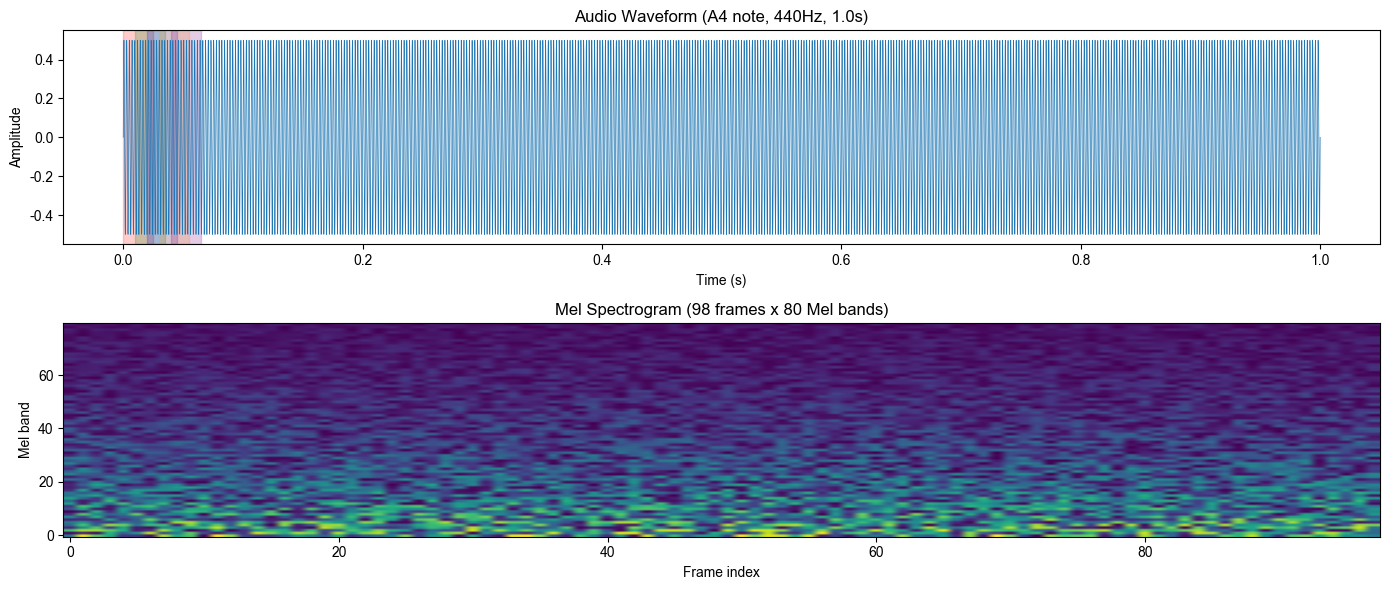


=== 音频分帧参数 ===
采样率: 16000 Hz
帧长: 25 ms (400 采样点)
帧移: 10 ms (160 采样点)
1 秒音频产生的帧数: 98

=== 音频 Token 数量估算 ===
    1秒音频 -> 98 帧 -> 经过声学模型后约 49~98 个音频 Token
    5秒音频 -> 490 帧 -> 经过声学模型后约 245~490 个音频 Token
   10秒音频 -> 980 帧 -> 经过声学模型后约 490~980 个音频 Token
   60秒音频 -> 5880 帧 -> 经过声学模型后约 2940~5880 个音频 Token

=== 对比: 同样 1 秒的内容 ===
  文本: ~5-10 个 Token
  图片 (3024x4032): ~11844 个视觉 Token
  音频: ~50-100 个音频 Token
  视频 (328x640, 13秒): ~2600 个视频 Token


In [7]:
sample_rate = 16000
frame_length = 25
frame_step = 10
duration_sec = 1.0

n_samples = int(sample_rate * duration_sec)
t = np.linspace(0, duration_sec, n_samples)
freq = 440
waveform = 0.5 * np.sin(2 * np.pi * freq * t)

frame_len_samples = int(sample_rate * frame_length / 1000)
frame_step_samples = int(sample_rate * frame_step / 1000)
n_frames = 1 + (n_samples - frame_len_samples) // frame_step_samples

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(t, waveform, linewidth=0.5)
axes[0].set_title(f"Audio Waveform (A4 note, {freq}Hz, {duration_sec}s)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

for i in range(min(5, n_frames)):
    start = i * frame_step_samples
    end = start + frame_len_samples
    axes[0].axvspan(start / sample_rate, end / sample_rate, alpha=0.2, color=['red', 'green', 'blue', 'orange', 'purple'][i])

n_mels = 80
np.random.seed(42)
mel_spec = np.random.rand(n_mels, n_frames) * 0.8
for f in range(n_mels):
    mel_spec[f, :] *= np.exp(-0.03 * f)

im = axes[1].imshow(mel_spec, aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title(f"Mel Spectrogram ({n_frames} frames x {n_mels} Mel bands)")
axes[1].set_xlabel("Frame index")
axes[1].set_ylabel("Mel band")

plt.tight_layout()
plt.show()

print(f"\n=== 音频分帧参数 ===")
print(f"采样率: {sample_rate} Hz")
print(f"帧长: {frame_length} ms ({frame_len_samples} 采样点)")
print(f"帧移: {frame_step} ms ({frame_step_samples} 采样点)")
print(f"1 秒音频产生的帧数: {n_frames}")
print(f"\n=== 音频 Token 数量估算 ===")
for dur in [1, 5, 10, 60]:
    frames = dur * n_frames
    print(f"  {dur:>3d}秒音频 -> {frames} 帧 -> 经过声学模型后约 {frames // 2}~{frames} 个音频 Token")

print(f"\n=== 对比: 同样 1 秒的内容 ===")
print(f"  文本: ~5-10 个 Token")
print(f"  图片 (3024x4032): ~11844 个视觉 Token")
print(f"  音频: ~50-100 个音频 Token")
print(f"  视频 (328x640, 13秒): ~2600 个视频 Token")

### TTS：从 Token 生成语音

上面讲的是音频**输入**的过程（听懂声音）。那声音**输出**（说话）呢？这就是 TTS (Text-to-Speech) 的工作。

Qwen3.5-Omni 的语音生成流程：

1. **Thinker** 生成文本思维，决定"说什么"。
2. **Talker** 将文本映射为多层 Codebook 的音频 Token。
3. **ARIA 对齐**：动态对齐文本和语音的输出节奏，避免"机器人说话"的感觉。
4. **Codec 解码器** 将音频 Token 还原为波形，得到可播放的音频。

这里的关键技术是 **Residual Vector Quantization (RVQ)**：音频被编码为多层 Codebook 索引，第一层捕捉粗略的音频特征，后续层捕捉越来越细节的残差信息。这就像一张图片的"渐进式加载"：先看到模糊的轮廓，再逐步清晰。

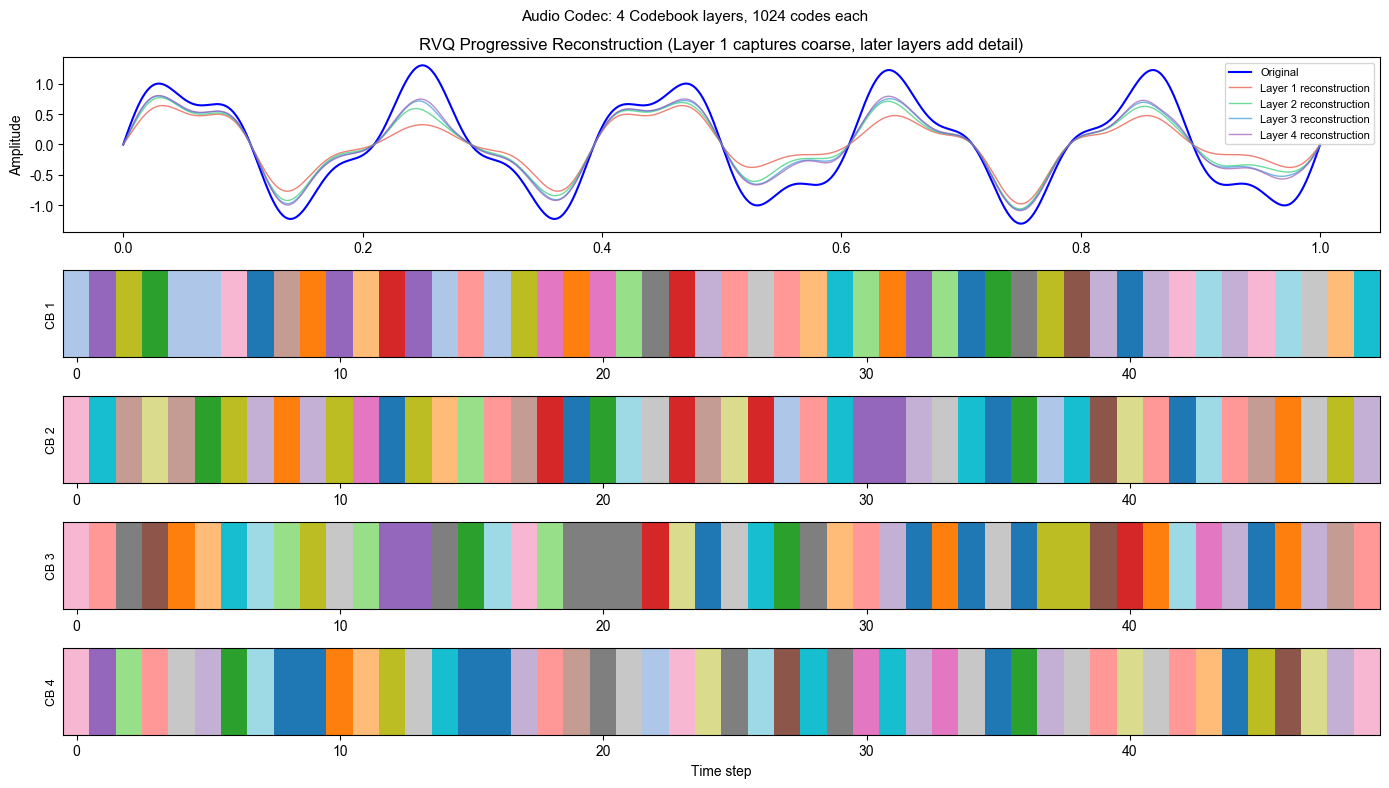


=== 音频 Codec 参数 ===
Codebook 层数: 4
每层码字数: 1024
总码字空间: 1099511627776 (理论上)
实际每个音频时间步的 Token 数: 4 个 Codebook 索引

对比文本 Token: 每个文本 Token 是 1 个 ID
对比音频 Token: 每个时间步需要 4 个 ID（多层 Codebook）


In [8]:
n_codebooks = 4
codebook_size = 1024
n_audio_tokens = 50

np.random.seed(42)
fig, axes = plt.subplots(n_codebooks + 1, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2] + [1]*n_codebooks})

t_audio = np.linspace(0, 1, 1000)
original = np.sin(2 * np.pi * 5 * t_audio) + 0.3 * np.sin(2 * np.pi * 13 * t_audio)
axes[0].plot(t_audio, original, 'b-', linewidth=1.5, label='Original')

reconstructed = np.zeros_like(original)
colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6']
residuals = [original.copy()]
for layer in range(n_codebooks):
    approx = residuals[-1] * (0.5 ** (layer + 1)) * (1 + 0.5 * np.sin(2 * np.pi * (3 + layer * 7) * t_audio))
    reconstructed += approx
    residuals.append(original - reconstructed)
    axes[0].plot(t_audio, reconstructed, color=colors[layer], linewidth=1, alpha=0.7,
                 label=f'Layer {layer+1} reconstruction')

axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_title('RVQ Progressive Reconstruction (Layer 1 captures coarse, later layers add detail)')
axes[0].set_ylabel('Amplitude')

for layer in range(n_codebooks):
    codes = np.random.randint(0, codebook_size, n_audio_tokens)
    axes[layer + 1].imshow([codes], aspect='auto', cmap='tab20', interpolation='nearest')
    axes[layer + 1].set_ylabel(f'CB {layer+1}', fontsize=9)
    axes[layer + 1].set_yticks([])
    if layer == n_codebooks - 1:
        axes[layer + 1].set_xlabel('Time step')

plt.suptitle(f'Audio Codec: {n_codebooks} Codebook layers, {codebook_size} codes each', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n=== 音频 Codec 参数 ===")
print(f"Codebook 层数: {n_codebooks}")
print(f"每层码字数: {codebook_size}")
print(f"总码字空间: {codebook_size ** n_codebooks} (理论上)")
print(f"实际每个音频时间步的 Token 数: {n_codebooks} 个 Codebook 索引")
print(f"\n对比文本 Token: 每个文本 Token 是 1 个 ID")
print(f"对比音频 Token: 每个时间步需要 {n_codebooks} 个 ID（多层 Codebook）")

## 4. 多模态融合：不同模态的 Token 如何共存？

现在我们已经了解了三种模态的 Token 是如何产生的。那它们在模型内部是如何"和平共处"的呢？

答案是：**所有模态的 Token 最终都被映射到同一个向量空间**，然后串接在一起，输入到同一个 Transformer 中处理。这就是"Everything is a Token"的真正含义。

具体来说，一个多模态输入的 Token 序列长这样：

```
[文本 Tokens] [vision_start] [视觉 Tokens...] [vision_end] [文本 Tokens] ...
```

关键设计：
- **视觉编码器** 的输出维度被映射为与文本 Embedding 相同的维度（Qwen3.5-0.8B 中是 1024）。
- **特殊标记 Token**（`vision_start`, `vision_end`）告诉模型"这里开始/结束是视觉内容"。
- **位置编码**：视觉 Token 使用特殊的 mRoPE（多维旋转位置编码），同时编码时间、竖直、水平三个维度的位置。
- **Transformer 不区分模态**：对 Transformer 来说，每个 Token 都是一个向量，无论它来自文本还是图片。

让我们用乖乖图片来验证这一点：

In [9]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": demo_img},
            {"type": "text", "text": "What is in this image?"},
        ],
    }
]

text_prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = processor(text=[text_prompt], images=[demo_img], return_tensors="pt")
input_ids = inputs["input_ids"][0]

print("=== 多模态 Token 序列结构 ===")
print(f"总 Token 数: {len(input_ids)}")

segments = []
current_type = None
current_start = 0

for idx, tid in enumerate(input_ids.tolist()):
    if tid == config.vision_start_token_id:
        if current_type and idx > current_start:
            segments.append((current_type, current_start, idx))
        current_type = "vision_start"
        current_start = idx
    elif tid == config.vision_end_token_id:
        if current_type and idx > current_start:
            segments.append((current_type, current_start, idx))
        current_type = "vision_end"
        current_start = idx
    elif tid == config.image_token_id:
        if current_type != "image":
            if current_type and idx > current_start:
                segments.append((current_type, current_start, idx))
            current_type = "image"
            current_start = idx
    else:
        if current_type != "text":
            if current_type and idx > current_start:
                segments.append((current_type, current_start, idx))
            current_type = "text"
            current_start = idx

if current_type and len(input_ids) > current_start:
    segments.append((current_type, current_start, len(input_ids)))

merged = []
for seg in segments:
    if merged and merged[-1][0] == seg[0]:
        merged[-1] = (seg[0], merged[-1][1], seg[2])
    else:
        merged.append(seg)

print(f"\n分段解读:")
type_labels = {
    "text": "文本",
    "image": "视觉",
    "vision_start": "视觉起始",
    "vision_end": "视觉结束",
}
for seg_type, start, end in merged:
    label = type_labels.get(seg_type, seg_type)
    n = end - start
    if seg_type == "text":
        text_content = tokenizer.decode(input_ids[start:end])
        preview = text_content[:50].replace('\n', '\\n')
        print(f"  [{label:6s}] pos {start:>3d}-{end-1:>3d} ({n:>3d} tokens): {preview!r}")
    else:
        print(f"  [{label:6s}] pos {start:>3d}-{end-1:>3d} ({n:>3d} tokens)")

print(f"\n=== 向量维度验证 ===")
text_embed_dim = config.text_config.hidden_size
vision_out_dim = config.vision_config.out_hidden_size
print(f"文本 Embedding 维度:    {text_embed_dim}")
print(f"视觉编码器输出维度: {vision_out_dim}")
print(f"两者一致: {text_embed_dim == vision_out_dim}")
print(f"\n这意味着视觉 Token 和文本 Token 在同一个向量空间中，Transformer 对它们一视同仁。")

=== 多模态 Token 序列结构 ===
总 Token 数: 356

分段解读:
  [文本    ] pos   0-  2 (  3 tokens): '<|im_start|>user\\n'
  [视觉起始  ] pos   3-  3 (  1 tokens)
  [视觉    ] pos   4-339 (336 tokens)
  [视觉结束  ] pos 340-340 (  1 tokens)
  [文本    ] pos 341-355 ( 15 tokens): 'What is in this image?<|im_end|>\\n<|im_start|>assis'

=== 向量维度验证 ===
文本 Embedding 维度:    1024
视觉编码器输出维度: 1024
两者一致: True

这意味着视觉 Token 和文本 Token 在同一个向量空间中，Transformer 对它们一视同仁。


### 多模态流式推理（带 KV Cache 加速）

最后，让我们用 Qwen3.5-0.8B 完成一次真正的多模态推理，看看模型能不能"看懂" 乖乖图片并回答问题。

**KV Cache 加速原理**：自回归生成中，每一步都要对整个序列做注意力计算。但前面已经算过的 Token 的 Key/Value 是不会变的！把它们缓存起来就是 **KV Cache** —— 每步只算新 Token 的 K/V，然后和缓存的 K/V 一起做注意力。每步计算量从 O(N) 降到 O(1)，总体从 O(N²) 降到 O(N)。对于多模态模型效果尤其显著，因为一张图片就有 336 个视觉 Token，视频更是 1664 个，重复计算它们的开销非常大。

我们使用 `model.generate()` + `TextIteratorStreamer` 实现流式输出，框架自动处理 KV Cache 和 Qwen3.5 特有的 mRoPE 位置编码。同时通过 `/no_think` 关闭思考模式（让模型直接回答），并使用 Qwen3.5 推荐的非思考模式采样参数（temperature=0.7, top_p=0.8, top_k=20）：

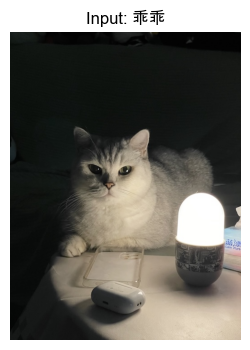

提问: 你从图里看到了什么？挑重点，禁止啰嗦
输入 Token 数（图片+提示词）: 363

流式生成中: 图中有一只银白相间、毛发蓬松的英国短毛猫，正坐在白色桌布上，面前放着一个透明手机壳、一个白色无线耳机和一个亮着的台灯。

【结束啦】耗时 193.4s


In [10]:
question = "你从图里看到了什么？挑重点，禁止啰嗦"

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": demo_img},
            {"type": "text", "text": question},
        ],
    }
]

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt",
    # 控制 enable_thinking 可以开关思考模式（仅对 Qwen3.5）
    enable_thinking=False  
)

plt.figure(figsize=(4, 4))
plt.imshow(demo_img)
plt.title("Input: 乖乖")
plt.axis('off')
plt.show()

print(f"提问: {question}")
print(f"输入 Token 数（图片+提示词）: {inputs['input_ids'].numel()}")
print(f"\n流式生成中: ", end="", flush=True)

streamer = TextIteratorStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)

generation_kwargs = dict(
    **inputs,
    streamer=streamer,
    max_new_tokens=256,
    temperature=0.7,
    top_p=0.8,
    top_k=20,
    repetition_penalty=1.0,
    do_sample=True,
)

import time
t0 = time.time()

thread = Thread(target=model.generate, kwargs=generation_kwargs)
thread.start()

for new_text in streamer:
    print(new_text, end="", flush=True)

thread.join()
elapsed = time.time() - t0
print(f"\n【结束啦】耗时 {elapsed:.1f}s")

### 视频流式推理（带 KV Cache 加速）

既然 Qwen3.5 也支持视频输入，让我们也试试用开源视频做一次流式推理。视频的 Token 数量更多（1664 个），KV Cache 的加速效果会更明显：

In [11]:
video_path = os.path.join(ASSETS_DIR, "guaiguai_ghibli_film.mp4")
print(f"视频文件: {video_path}")

question = "视频里发生了什么？挑重点，禁止啰嗦 /no_think"
messages_v = [
    {
        "role": "user",
        "content": [
            {"type": "video", "video": video_path},
            {"type": "text", "text": question},
        ],
    }
]

inputs_v = processor.apply_chat_template(
    messages_v,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt",
)

n_video_tok = (inputs_v["input_ids"] == config.video_token_id).sum().item()
print(f"提问: {question}")
print(f"视频 Token 数量: {n_video_tok}")
print(f"\n流式生成中: ", end="", flush=True)

streamer_v = TextIteratorStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)

generation_kwargs_v = dict(
    **inputs_v,
    streamer=streamer_v,
    max_new_tokens=256,
    temperature=0.7,
    top_p=0.8,
    top_k=20,
    repetition_penalty=1.0,
    do_sample=True,
)

import time
t0_v = time.time()

thread_v = Thread(target=model.generate, kwargs=generation_kwargs_v)
thread_v.start()

for new_text in streamer_v:
    print(new_text, end="", flush=True)

thread_v.join()
elapsed_v = time.time() - t0_v
print(f"\n【结束啦】耗时 {elapsed_v:.1f}s")

视频文件: /Users/rongtao/Desktop/LLMPrimer/01-token_journey/guaiguai_ghibli_film.mp4
提问: 视频里发生了什么？挑重点，禁止啰嗦 /no_think
视频 Token 数量: 1664

流式生成中: 视频中展示了一只白色的猫坐在电视柜上，背景是白色的墙壁和一台黑色的微波炉。电视柜上有一些玩具和装饰品，包括一个黄色的鸭子玩偶和其他的小动物玩偶。猫的表情看起来很平静，似乎在等待什么。画面中还有一些文字，写着“你想活成怎样的人生”，这似乎是一个励志或自我激励的口号。整个场景给人一种温馨、宁静的感觉。

【结束啦】耗时 357.2s


## 5. 语音交互：听懂你的声音，用声音回答

前面我们展示了图片和视频的推理。现在让我们把**音频**也加进来，体验真正的多模态交互！

我们将使用两个开源工具：
- **Whisper**（OpenAI 开源）：将语音转为文字（ASR，语音识别）
- **edge-tts**（微软开源 TTS）：将文字转为语音（TTS，语音合成）

整个流程：**录音 → Whisper 识别 → Qwen3.5 看图推理 → edge-tts 语音回答**

### 5.1 语音识别（ASR）：从声音到文字

In [12]:
import whisper
import sounddevice as sd
import soundfile as sf
import warnings
warnings.filterwarnings("ignore", message="FP16 is not supported on CPU")

print("加载 Whisper 模型 (tiny)...")
whisper_model = whisper.load_model("tiny")
print("Whisper 模型加载完成！")
print(f"\nWhisper 将音频波形 -> 分帧 -> Mel 频谱 -> Transformer 编码器 -> 文字")
print(f"这就是“音频输入”的完整链路：声音 -> Token -> 文字")

加载 Whisper 模型 (tiny)...
Whisper 模型加载完成！

Whisper 将音频波形 -> 分帧 -> Mel 频谱 -> Transformer 编码器 -> 文字
这就是“音频输入”的完整链路：声音 -> Token -> 文字


### 5.2 语音合成（TTS）：从文字到声音

TTS 是 ASR 的逆过程：文字 -> 音频 Token -> 声音波形。我们使用 edge-tts 来演示：

In [13]:
import asyncio
import edge_tts
from IPython.display import Audio, display

async def text_to_speech(text, output_path, voice="zh-CN-XiaoxiaoNeural"):
    communicate = edge_tts.Communicate(text, voice)
    await communicate.save(output_path)
    return output_path

demo_text = "你好！我是Qwen多模态模型，我能看图说话，也能听懂你的声音！"
tts_path = os.path.join(tempfile.gettempdir(), "demo_tts.wav")

print(f"TTS 输入: {demo_text!r}")
print(f"\nTTS 流程: 文字 -> 音频 Token (多层 Codebook) -> 声音波形")
print(f"生成语音中...")

await text_to_speech(demo_text, tts_path)
print(f"语音已保存: {tts_path} ({os.path.getsize(tts_path)/1024:.1f} KB)")

print(f"\n播放 TTS 生成的语音:")
display(Audio(tts_path))

if os.path.exists(tts_path):
    os.remove(tts_path)
    print(f"\n临时文件已清理: {tts_path}")

TTS 输入: '你好！我是Qwen多模态模型，我能看图说话，也能听懂你的声音！'

TTS 流程: 文字 -> 音频 Token (多层 Codebook) -> 声音波形
生成语音中...
语音已保存: /Users/rongtao/Desktop/LLMPrimer/01-token_journey/demo_tts.wav (37.7 KB)

播放 TTS 生成的语音:


### 5.3 录音并识别

现在让我们录制一段语音，然后用 Whisper 识别。运行下面的单元格后，请对着麦克风说话（比如问一个关于乖乖图片的问题）：

In [14]:
RECORD_SECONDS = 5
SAMPLE_RATE = 16000

print(f"准备录音 {RECORD_SECONDS} 秒...")
print(f"3...")
import time; time.sleep(1)
print(f"2...")
time.sleep(1)
print(f"1...")
time.sleep(1)
print(f"开始录音！请说话...")

recording = sd.rec(int(RECORD_SECONDS * SAMPLE_RATE), samplerate=SAMPLE_RATE, channels=1, dtype='float32')
sd.wait()

record_path = os.path.join(tempfile.gettempdir(), "user_recording.wav")
sf.write(record_path, recording, SAMPLE_RATE)
print(f"录音完成！保存到: {record_path}")

print(f"\n播放录音:")
display(Audio(record_path))

print(f"\nWhisper 识别中...")
result = whisper_model.transcribe(record_path)
user_question = result['text'].strip()
print(f"识别结果: {user_question!r}")

if os.path.exists(record_path):
    os.remove(record_path)
    print(f"\n临时文件已清理: {record_path}")

if not user_question:
    print(f"\n未检测到语音，使用默认问题: \"请描述这张图片\"")
    user_question = "请描述这张图片"

准备录音 5 秒...
3...
2...
1...
开始录音！请说话...
录音完成！保存到: /Users/rongtao/Desktop/LLMPrimer/01-token_journey/user_recording.wav

播放录音:



Whisper 识别中...
识别结果: ''

未检测到语音，使用默认问题: "请描述这张图片"


### 5.4 完整交互：语音提问 → 看图推理 → 语音回答

现在我们把所有模块串起来：用你的语音提问，Qwen3.5 看乖乖图片后回答，然后用语音播放回答！

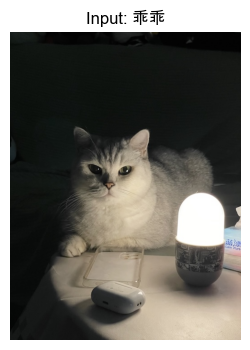

你的问题: 请描述这张图片

Qwen3.5 流式回答: 这张图片展示了一只毛色为银灰色与白色相间的英国短毛猫，它正安静地趴在一张铺有白色桌布的桌子上，眼神专注地凝视着镜头，表情略带一丝慵懒或沉思。

猫的右侧（画面右侧）放着一个正在发光的台灯，灯罩呈圆形，底部有花纹装饰，发出明亮的光晕，照亮了猫的头部和部分桌面。在猫的左前方，有一个透明手机壳，里面似乎放着一部手机；手机壳下方是一个白色的小型无线耳机或蓝牙音箱，正散发着柔和的光。

背景较暗，隐约可见深色沙发或床铺的轮廓，营造出一种室内夜间或傍晚的宁静氛围。整体画面光线集中在猫和台灯区域，突出主体，同时通过阴影增强了画面的层次感和温馨感。

总结：这是一张温馨的生活场景照片，捕捉了一只猫咪在柔和灯光下凝视的瞬间，充满了生活气息与宁静美感。

生成耗时 893.2s


将回答转为语音...
语音已生成: /Users/rongtao/Desktop/LLMPrimer/01-token_journey/response_audio.wav (392.2 KB)

播放语音回答:


In [15]:
messages_interactive = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": demo_img},
            {"type": "text", "text": user_question + " /no_think"},
        ],
    }
]

inputs_i = processor.apply_chat_template(
    messages_interactive,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt",
)

plt.figure(figsize=(4, 4))
plt.imshow(demo_img)
plt.title("Input: 乖乖")
plt.axis('off')
plt.show()

print(f"你的问题: {user_question}")
print(f"\nQwen3.5 流式回答: ", end="", flush=True)

streamer_i = TextIteratorStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)

generation_kwargs_i = dict(
    **inputs_i,
    streamer=streamer_i,
    max_new_tokens=256,
    temperature=0.7,
    top_p=0.8,
    top_k=20,
    repetition_penalty=1.0,
    do_sample=True,
)

import time
t0_i = time.time()

thread_i = Thread(target=model.generate, kwargs=generation_kwargs_i)
thread_i.start()

generated_text = ""
for new_text in streamer_i:
    print(new_text, end="", flush=True)
    generated_text += new_text

thread_i.join()
elapsed_i = time.time() - t0_i
print(f"\n生成耗时 {elapsed_i:.1f}s\n")

response_text = generated_text.strip()

print(f"\n将回答转为语音...")
response_audio_path = os.path.join(tempfile.gettempdir(), "response_audio.wav")
await text_to_speech(response_text, response_audio_path)
print(f"语音已生成: {response_audio_path} ({os.path.getsize(response_audio_path)/1024:.1f} KB)")

print(f"\n播放语音回答:")
display(Audio(response_audio_path))

if os.path.exists(response_audio_path):
    os.remove(response_audio_path)
    print(f"\n临时文件已清理: {response_audio_path}")

## 结语

通过这节课，我们深入探索了多模态 Token 的世界：

| 模态 | 输入形式 | 分词方式 | 实际验证 |
|------|--------|--------|------|
| 文本 | 字符串 | BPE 分词 | 每个 Token 对应一个 ID，词表固定 |
| 图片 | 像素矩阵 | ViT Patch 切分 + 空间合并 | 乖乖图片 (3024x4032) → 11844 个视觉 Token |
| 视频 | 帧序列 | 时间 Patch + 空间合并 | 吉卜力风格视频 (328x640, 13秒) → 2600 个视频 Token |
| 音频 | 波形 | 分帧 + 声学模型 / Codec | Whisper ASR + edge-tts TTS 交互演示 |

核心洞察：**所有模态的信息最终都被映射到同一个向量空间，作为统一的 Token 序列输入 Transformer。** 这就是"Everything is a Token"的真正含义 —— 不管是文字、图片、视频还是声音，在模型眼里都是同一种"语言"。

Qwen3.5 家族的设计哲学尤其值得关注：从 0.8B 到 397B，**每个模型都原生支持图片和视频**，不再需要单独的"VL"版本。这意味着多模态能力不再是"加上去的"，而是"长在里面的"。而 Qwen3.5-Omni 更进一步，将音频也统一进来，实现了真正的"万物皆 Token"。